In [1]:
# Import required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

In [2]:
# Setting up file paths
train_path = '/kaggle/input/kermany2018/OCT2017 /train'
test_path = '/kaggle/input/kermany2018/OCT2017 /test'
val_path = '/kaggle/input/kermany2018/OCT2017 /val'

In [3]:
categories = ['CNV', 'DME', 'DRUSEN', 'NORMAL']

# EDA: Count number of images per category in each set
def count_images_in_directory(directory):
    category_count = {}
    for category in categories:
        category_path = os.path.join(directory, category)
        category_count[category] = len(os.listdir(category_path))
    return category_count

# Get image distribution for train, validation, and test sets
train_distribution = count_images_in_directory(train_path)
test_distribution = count_images_in_directory(test_path)
val_distribution = count_images_in_directory(val_path)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


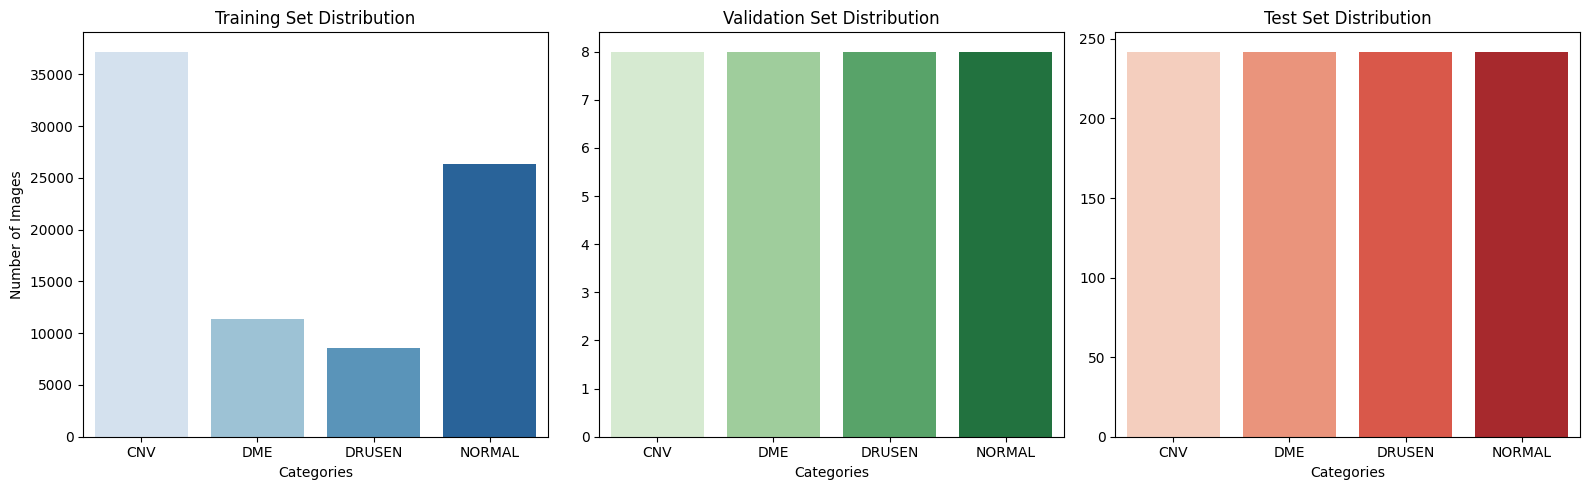

In [4]:
# Plot the distribution of images across categories for train, validation, and test sets
def plot_class_distribution():
    plt.figure(figsize=(16, 5))
    
    plt.subplot(1, 3, 1)
    sns.barplot(x=list(train_distribution.keys()), y=list(train_distribution.values()), palette="Blues")
    plt.title("Training Set Distribution")
    plt.xlabel("Categories")
    plt.ylabel("Number of Images")
    
    plt.subplot(1, 3, 2)
    sns.barplot(x=list(val_distribution.keys()), y=list(val_distribution.values()), palette="Greens")
    plt.title("Validation Set Distribution")
    plt.xlabel("Categories")
    
    plt.subplot(1, 3, 3)
    sns.barplot(x=list(test_distribution.keys()), y=list(test_distribution.values()), palette="Reds")
    plt.title("Test Set Distribution")
    plt.xlabel("Categories")
    
    plt.tight_layout()
    plt.show()

# Display class distribution plots
plot_class_distribution()

In [5]:
# Image preprocessing using ImageDataGenerator
img_size = (128, 128)
batch_size = 32

In [6]:
# Augmentation and rescaling for training set
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=10, width_shift_range=0.2, height_shift_range=0.2, zoom_range=0.2, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [7]:
# Data Generators
train_generator = train_datagen.flow_from_directory(train_path, target_size=img_size, batch_size=batch_size, class_mode='categorical')
val_generator = val_datagen.flow_from_directory(val_path, target_size=img_size, batch_size=batch_size, class_mode='categorical')
test_generator = test_datagen.flow_from_directory(test_path, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False)

Found 83484 images belonging to 4 classes.
Found 32 images belonging to 4 classes.
Found 968 images belonging to 4 classes.


In [8]:
# Build CNN model
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(4, activation='softmax')
])

/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [10]:
# Model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Model training
history = model.fit(train_generator, validation_data=val_generator, epochs=10)

Epoch 1/10


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1727389322.473625      88 service.cc:145] XLA service 0x78e564005340 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1727389322.473679      88 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1727389322.473682      88 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


   1/2609 ━━━━━━━━━━━━━━━━━━━━ 6:23:49 9s/step - accuracy: 0.2500 - loss: 1.4024

I0000 00:00:1727389327.162664      88 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2609/2609 ━━━━━━━━━━━━━━━━━━━━ 941s 358ms/step - accuracy: 0.6294 - loss: 0.9436 - val_accuracy: 0.6250 - val_loss: 1.0383
Epoch 2/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 684s 261ms/step - accuracy: 0.7785 - loss: 0.6008 - val_accuracy: 0.8750 - val_loss: 0.3809
Epoch 3/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 634s 242ms/step - accuracy: 0.8443 - loss: 0.4468 - val_accuracy: 0.9688 - val_loss: 0.1631
Epoch 4/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 609s 233ms/step - accuracy: 0.8715 - loss: 0.3778 - val_accuracy: 0.9688 - val_loss: 0.1232
Epoch 5/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 617s 231ms/step - accuracy: 0.8838 - loss: 0.3399 - val_accuracy: 1.0000 - val_loss: 0.0429
Epoch 6/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 605s 231ms/step - accuracy: 0.8924 - loss: 0.3226 - val_accuracy: 0.9375 - val_loss: 0.1237
Epoch 7/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 611s 234ms/step - accuracy: 0.8973 - loss: 0.3097 - val_accuracy: 1.0000 - val_loss: 0.0730
Epoch 8/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 618s 232ms/step - accuracy: 0.8

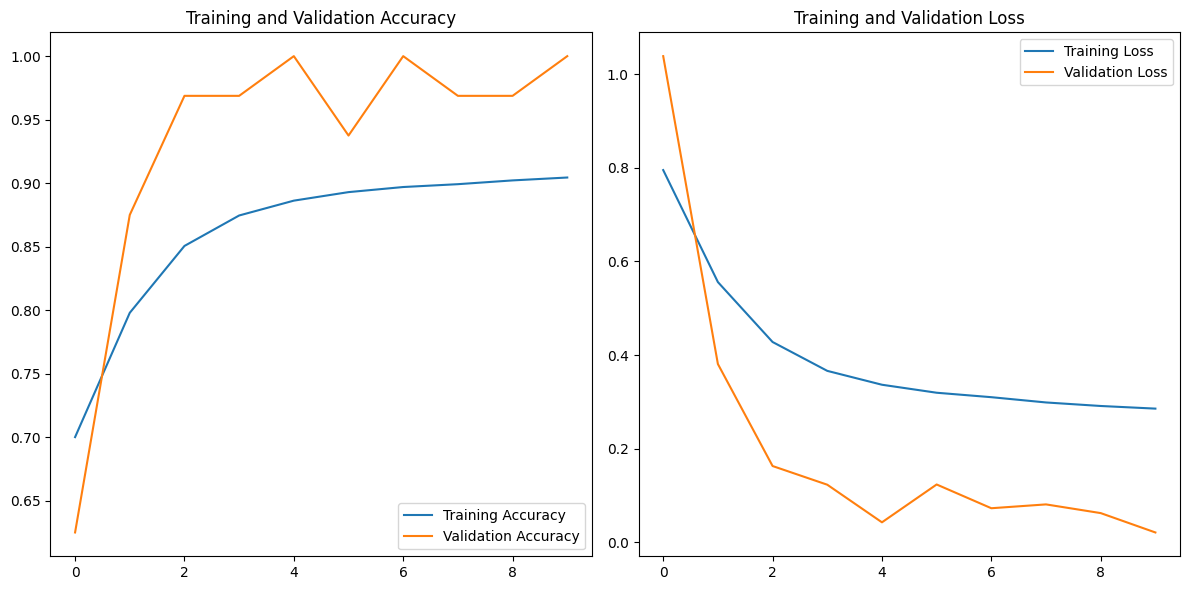

In [12]:
# Learning Curves for Accuracy and Loss
def plot_learning_curves(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 6))
    
    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')

    plt.tight_layout()
    plt.show()

# Plot learning curves
plot_learning_curves(history)

In [13]:
# Evaluate model on test set
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test Accuracy: {test_acc * 100:.2f}%')

31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 349ms/step - accuracy: 0.9695 - loss: 0.1035
Test Accuracy: 96.90%


In [14]:
# Predicting on the test set
test_predictions = model.predict(test_generator)
test_predictions_labels = np.argmax(test_predictions, axis=1)
true_labels = test_generator.classes

31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step


In [15]:
# Classification report
class_report = classification_report(true_labels, test_predictions_labels, target_names=categories)
print("Classification Report:")
print(class_report)

Classification Report:
              precision    recall  f1-score   support

         CNV       0.93      0.99      0.96       242
         DME       0.99      0.91      0.95       242
      DRUSEN       1.00      0.98      0.99       242
      NORMAL       0.96      1.00      0.98       242

    accuracy                           0.97       968
   macro avg       0.97      0.97      0.97       968
weighted avg       0.97      0.97      0.97       968



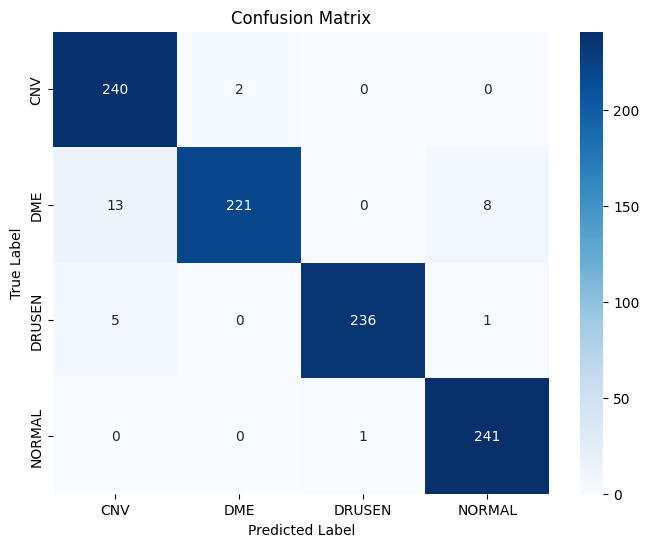

In [16]:
# Confusion matrix
conf_matrix = confusion_matrix(true_labels, test_predictions_labels)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=categories, yticklabels=categories)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

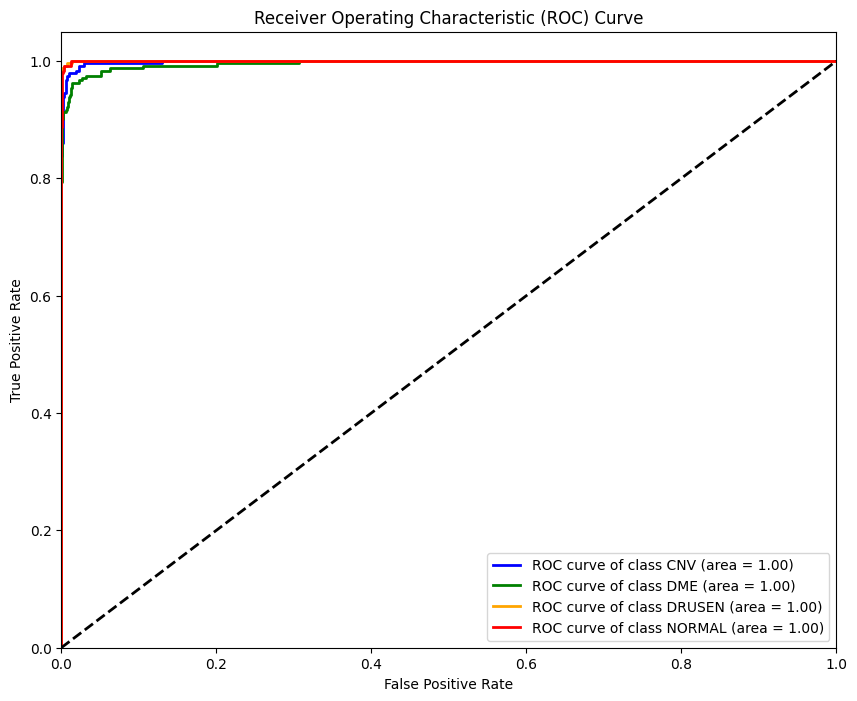

In [17]:
# ROC Curve for Multi-class Classification
def plot_multiclass_roc(test_labels, test_predictions):
    test_labels_binarized = label_binarize(test_labels, classes=[0, 1, 2, 3])
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(len(categories)):
        fpr[i], tpr[i], _ = roc_curve(test_labels_binarized[:, i], test_predictions[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    plt.figure(figsize=(10, 8))
    for i, color in zip(range(len(categories)), ['blue', 'green', 'orange', 'red']):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'ROC curve of class {categories[i]} (area = {roc_auc[i]:0.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

# Plot ROC Curve for multi-class
plot_multiclass_roc(true_labels, test_predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step


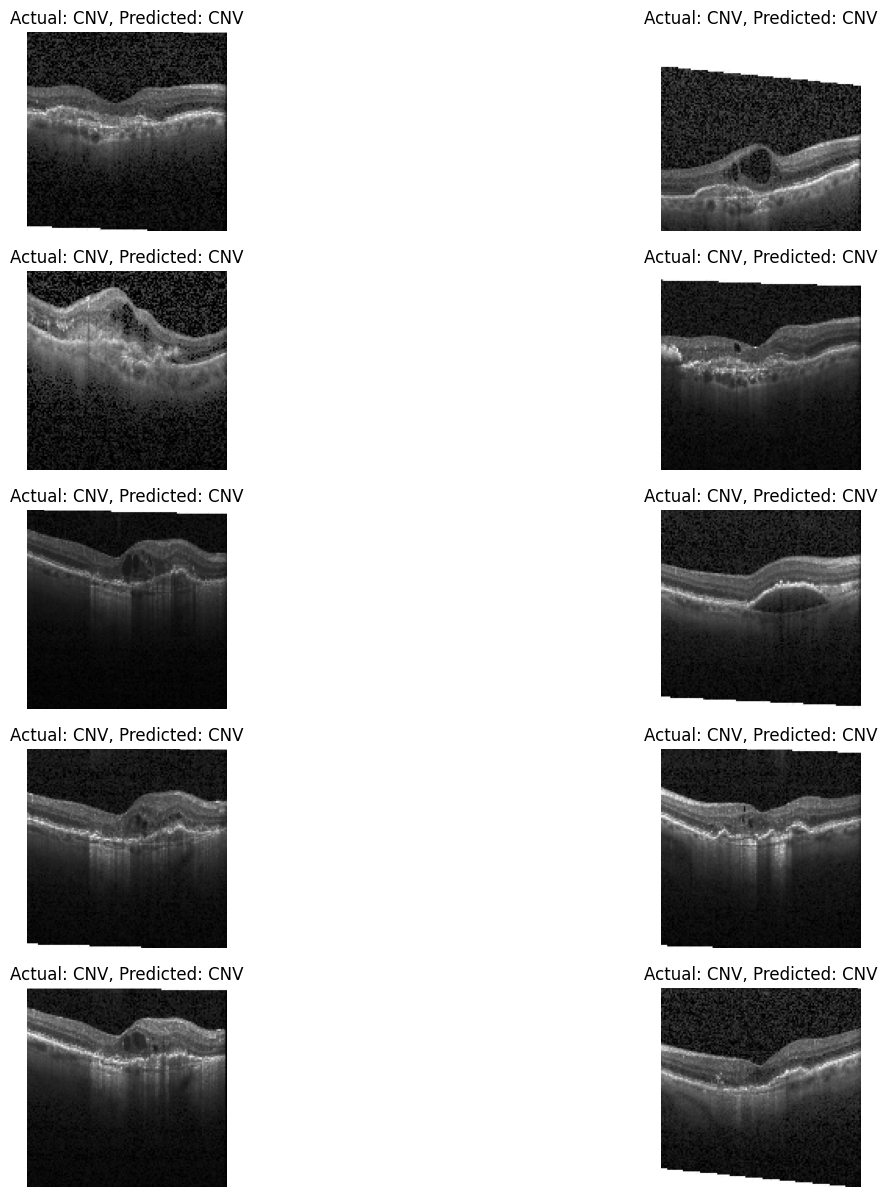

In [18]:
# Display 10 sample predictions with actual and predicted labels
def plot_sample_predictions(test_generator, num_samples=10):
    test_generator.reset()
    sample_images, sample_labels = next(test_generator)
    predictions = model.predict(sample_images)
    predicted_labels = np.argmax(predictions, axis=1)
    
    plt.figure(figsize=(15, 15))
    for i in range(num_samples):
        plt.subplot(5, 2, i+1)
        plt.imshow(sample_images[i])
        plt.title(f"Actual: {categories[np.argmax(sample_labels[i])]}, Predicted: {categories[predicted_labels[i]]}")
        plt.axis('off')
    plt.show()

# Show 10 samples with predictions
plot_sample_predictions(test_generator)

In [19]:
# Save the model
model.save('/kaggle/working/oct_model.h5')